# Chess Game Outcome Prediction

This notebook predicts the outcome of Titled Tuesday blitz games (win / draw / loss for White) using **only pre-game information**: player ratings, titles, and cumulative tournament standings.

**Data**: Chess.com PubAPI — February 10, 2026 tournament (train) and March 10, 2026 tournament (test).
**Approach**: Elo baseline → Logistic Regression → XGBoost, evaluated with a strict temporal split.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import setup_logging
setup_logging()

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 1. Data Collection

All API responses are cached locally in `data/raw/` after the first run — the notebook runs fully offline on subsequent executions.

In [2]:
from src.data_collection import fetch_tournament_games

games_train = fetch_tournament_games("train")
games_test  = fetch_tournament_games("test")

print(f"Train (February): {len(games_train)} games")
print(f"Test  (March):    {len(games_test)} games")

11:36:20 [INFO] src.data_collection: Tournament cache hit: titled-tuesday-blitz-february-10-2026-6221327


11:36:20 [INFO] src.data_collection: Found 11 rounds for tournament titled-tuesday-blitz-february-10-2026-6221327


11:36:20 [INFO] src.data_collection: Collected 2025 raw games for split 'train'


11:36:20 [INFO] src.data_collection: Fetching profiles for 450 unique players


11:36:20 [INFO] src.data_collection: Collected 2025 games for split 'train'


...

11:36:20 [INFO] src.data_collection: Found 11 rounds for tournament titled-tuesday-blitz-march-10-2026-6277141


11:36:20 [INFO] src.data_collection: Collected 2038 raw games for split 'test'


11:36:20 [INFO] src.data_collection: Fetching profiles for 467 unique players


11:36:21 [INFO] src.data_collection: Collected 2038 games for split 'test'


Train (February): 2025 games
Test  (March):    2038 games


In [3]:
# Sample rows — pgn excluded (post-game, never used as feature)
sample_cols = ["round_number", "white_username", "white_rating", "white_title",
               "black_username", "black_rating", "black_title", "white_result"]
pd.DataFrame(games_train)[sample_cols].head(6)

,round_number,white_username,white_rating,white_title,black_username,black_rating,black_title,white_result
0,1,UmutErdemGunduz,2682,IM,Hikaru,3316,GM,timeout
1,1,lachesisQ,3279,GM,GorinDeshi,2678,IM,win
2,1,JaiSankarS,2677,FM,NikoTheodorou,3252,GM,checkmated
3,1,GMWSO,3230,GM,GCamachoMartinez,2691,FM,resigned
4,1,dey2580,2675,IM,GHANDEEVAM2003,3233,GM,resigned
5,1,Oleksandr_Bortnyk,3228,GM,sn2022s,2673,CM,win


## 2. Exploratory Data Analysis

In [4]:
from src.features import build_features, get_feature_columns, map_outcome

df_train = build_features(games_train)
df_test  = build_features(games_test)
feature_cols = get_feature_columns(df_train)

label_map = {0: "Black wins", 1: "Draw", 2: "White wins"}
df_train["outcome_label"] = df_train["outcome"].map(label_map)
df_test["outcome_label"]  = df_test["outcome"].map(label_map)

11:36:21 [INFO] src.features: Built feature matrix: 2025 rows x 32 cols | outcome dist: {2: 987, 0: 874, 1: 164}


11:36:21 [INFO] src.features: Built feature matrix: 2038 rows x 32 cols | outcome dist: {2: 964, 0: 923, 1: 151}


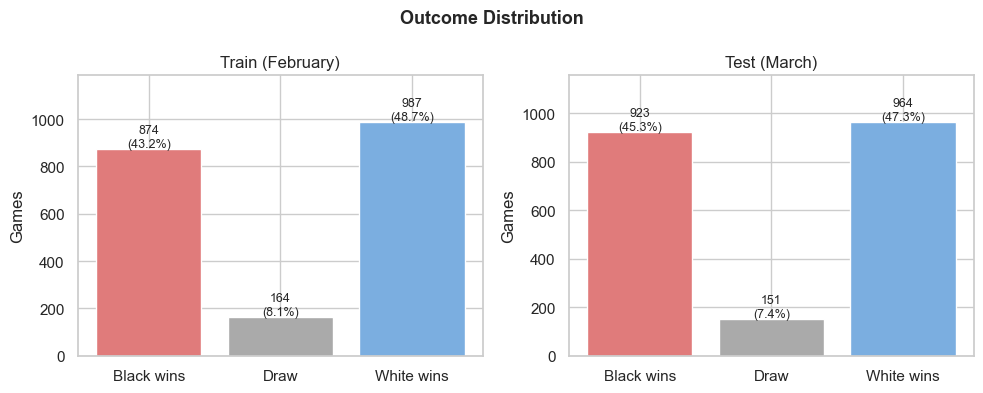

In [5]:
# Outcome class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (df, title) in zip(axes, [(df_train, "Train (February)"), (df_test, "Test (March)")]):
    counts = df["outcome_label"].value_counts().reindex(["Black wins", "Draw", "White wins"])
    ax.bar(counts.index, counts.values, color=["#e07b7b", "#aaaaaa", "#7baee0"])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Games")
    ax.set_ylim(0, counts.max() * 1.2)
fig.suptitle("Outcome Distribution", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

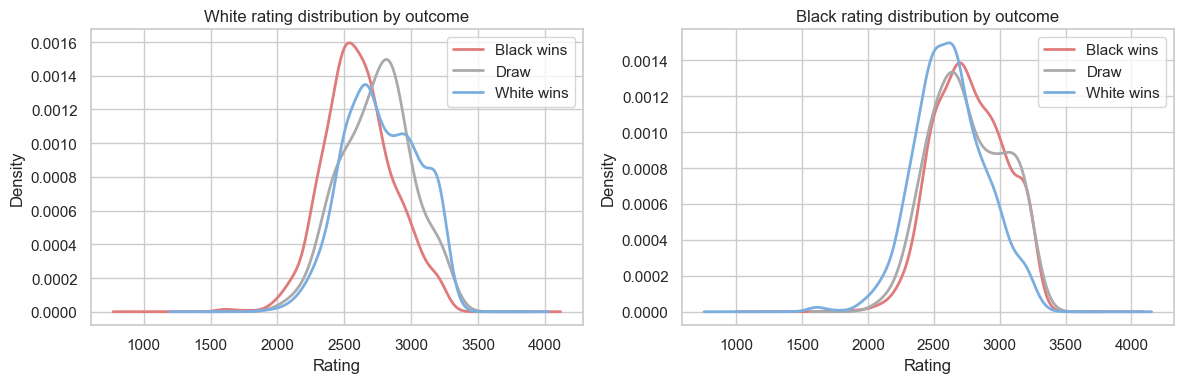

In [6]:
# Rating distributions by outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes,
        ["white_rating", "black_rating"],
        ["White rating", "Black rating"]):
    for outcome_label, color in zip(["Black wins", "Draw", "White wins"],
                                    ["#e07b7b", "#aaaaaa", "#7baee0"]):
        subset = df_train[df_train["outcome_label"] == outcome_label][col]
        subset.plot.kde(ax=ax, label=outcome_label, color=color, linewidth=2)
    ax.set_title(f"{label} distribution by outcome")
    ax.set_xlabel("Rating")
    ax.legend()
fig.tight_layout()
plt.show()

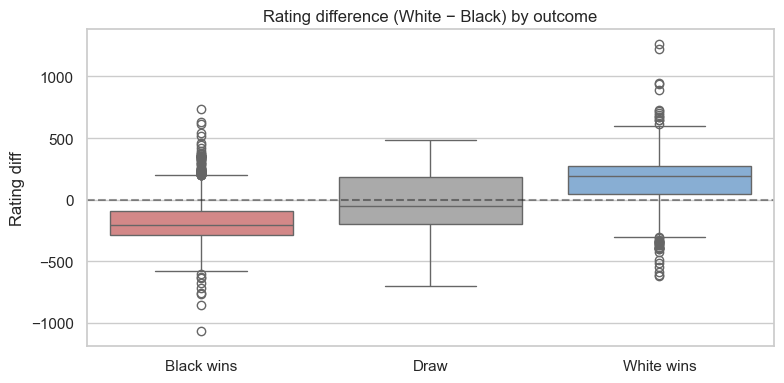

In [7]:
# Outcome vs rating difference
fig, ax = plt.subplots(figsize=(8, 4))
order = ["Black wins", "Draw", "White wins"]
colors = ["#e07b7b", "#aaaaaa", "#7baee0"]
df_train["rating_diff_plot"] = df_train["white_rating"] - df_train["black_rating"]
sns.boxplot(data=df_train, x="outcome_label", y="rating_diff_plot",
            order=order, palette=colors, ax=ax)
ax.axhline(0, linestyle="--", color="black", alpha=0.4)
ax.set_title("Rating difference (White − Black) by outcome")
ax.set_xlabel("")
ax.set_ylabel("Rating diff")
fig.tight_layout()
plt.show()

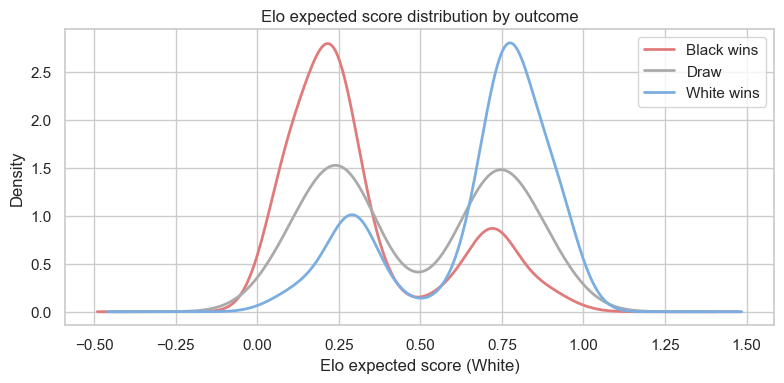

In [8]:
# Elo expected score distribution by outcome
fig, ax = plt.subplots(figsize=(8, 4))
for outcome_label, color in zip(["Black wins", "Draw", "White wins"],
                                 ["#e07b7b", "#aaaaaa", "#7baee0"]):
    subset = df_train[df_train["outcome_label"] == outcome_label]["elo_expected_score"]
    subset.plot.kde(ax=ax, label=outcome_label, color=color, linewidth=2)
ax.set_title("Elo expected score distribution by outcome")
ax.set_xlabel("Elo expected score (White)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Feature Engineering

Features are grouped into three families — all computed from pre-game data only.

In [9]:
print(f"Feature matrix shape: {df_train[feature_cols].shape}")
print(f"\nFeature groups:")
print(f"  Rating features     : white_rating, black_rating, rating_diff, rating_avg, abs_rating_diff, elo_expected_score")
print(f"  Tournament context  : round_number, white/black_tournament_points, tournament_points_diff")
print(f"  Title binary (×2)   : GM, IM, FM, WGM, WIM, CM, NM, WFM, WCM")
df_train[feature_cols].describe().round(2)

Feature matrix shape: (2025, 28)

Feature groups:
  Rating features     : white_rating, black_rating, rating_diff, rating_avg, abs_rating_diff, elo_expected_score
  Tournament context  : round_number, white/black_tournament_points, tournament_points_diff
  Title binary (×2)   : GM, IM, FM, WGM, WIM, CM, NM, WFM, WCM


,white_rating,black_rating,rating_diff,rating_avg,abs_rating_diff,elo_expected_score,round_number,white_tournament_points,black_tournament_points,tournament_points_diff,white_is_GM,black_is_GM,white_is_IM,black_is_IM,white_is_FM,black_is_FM,white_is_WGM,black_is_WGM,white_is_WIM,black_is_WIM,white_is_CM,black_is_CM,white_is_NM,black_is_NM,white_is_WFM,black_is_WFM,white_is_WCM,black_is_WCM
count,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00
mean,2701.26,2698.07,3.20,2699.67,242.74,0.50,5.62,2.33,2.34,-0.00,0.22,0.21,0.15,0.16,0.25,0.26,0.01,0.01,0.02,0.02,0.18,0.18,0.11,0.10,0.03,0.03,0.02,0.02
std,277.27,276.53,273.67,240.73,126.32,0.30,3.09,1.91,1.92,0.12,0.41,0.41,0.36,0.37,0.44,0.44,0.08,0.09,0.14,0.15,0.39,0.39,0.32,0.31,0.17,0.17,0.14,0.15
min,1608.00,1604.00,-1069.00,1937.50,2.00,0.00,1.00,0.00,0.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2505.00,2505.00,-211.00,2528.50,163.00,0.23,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2680.00,2681.00,42.00,2684.50,212.00,0.56,5.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2910.00,2904.00,212.00,2874.00,299.00,0.77,8.00,3.50,3.50,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,3317.00,3316.00,1265.00,3264.50,1265.00,1.00,11.00,8.50,9.50,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


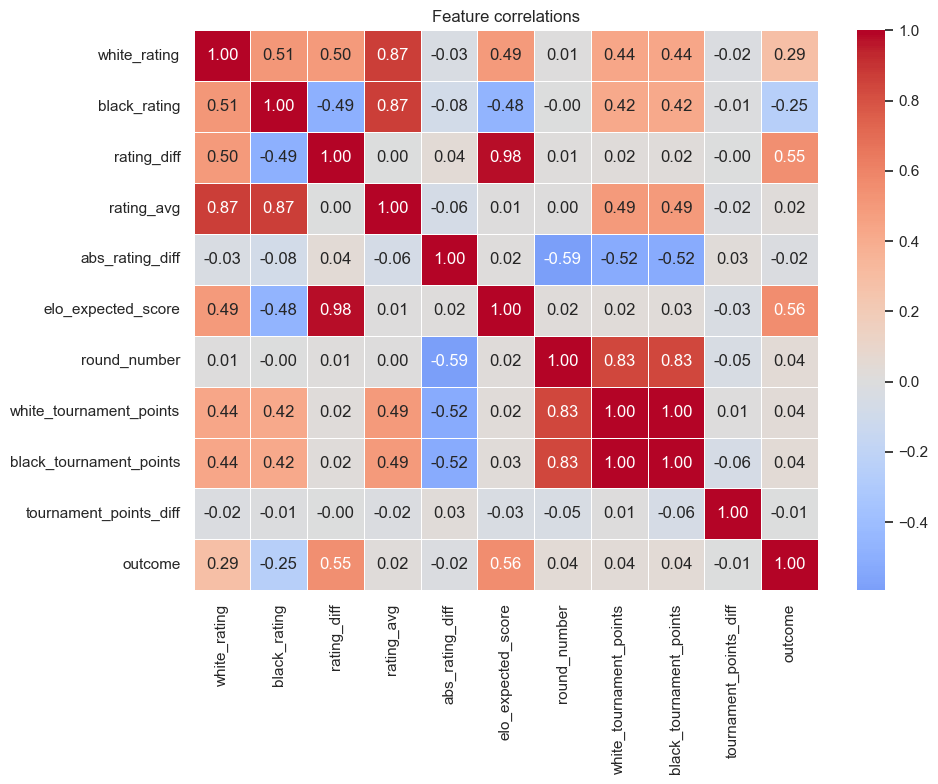

In [10]:
# Feature correlation heatmap (numeric features only)
numeric_features = ["white_rating", "black_rating", "rating_diff", "rating_avg",
                    "abs_rating_diff", "elo_expected_score", "round_number",
                    "white_tournament_points", "black_tournament_points",
                    "tournament_points_diff", "outcome"]
corr = df_train[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature correlations")
fig.tight_layout()
plt.show()

## 4. Modeling & Evaluation

**Split strategy**: Train on February tournament, test on March tournament.
This is a strict temporal split — no data from the test period is ever seen during training.
Cross-validation within training uses round number as the split criterion (rounds 1–8 train, 9–11 val).

In [11]:
from src.modeling import run_pipeline, plot_confusion_matrices, plot_feature_importance

output = run_pipeline(df_train, df_test, feature_cols)

11:36:22 [INFO] src.modeling: Elo baseline thresholds: low=0.44 high=0.50 | draw_rate=0.081


11:36:22 [INFO] src.modeling: Elo baseline — log_loss=0.7352  accuracy=0.6968


11:36:22 [INFO] src.modeling: Logistic regression trained on 2025 samples


11:36:22 [INFO] src.modeling: Logistic Regression — log_loss=0.7631  accuracy=0.6992


11:36:23 [INFO] src.modeling: XGBoost trained on 2025 samples


11:36:23 [INFO] src.modeling: XGBoost — log_loss=0.7824  accuracy=0.7041


11:36:23 [INFO] src.modeling: Elo baseline — log_loss=0.7484  accuracy=0.7002


11:36:23 [INFO] src.modeling: Logistic Regression — log_loss=0.7242  accuracy=0.7037


11:36:23 [INFO] src.modeling: XGBoost — log_loss=0.4523  accuracy=0.8356


In [12]:
print("=== TRAIN performance (February) ===")
display(output["comparison_train"])

print("\n=== TEST performance (March) ===")
display(output["comparison_test"])

=== TRAIN performance (February) ===


,Log-loss,Accuracy,F1 black_wins,F1 draw,F1 white_wins
Model,,,,,
Elo baseline,0.7484,0.7002,0.7212,0.0000,0.7399
Logistic Regression,0.7242,0.7037,0.7218,0.0119,0.7445
XGBoost,0.4523,0.8356,0.8557,0.3483,0.8656



=== TEST performance (March) ===


,Log-loss,Accuracy,F1 black_wins,F1 draw,F1 white_wins
Model,,,,,
Elo baseline,0.7352,0.6968,0.7226,0.000,0.7260
Logistic Regression,0.7631,0.6992,0.7231,0.000,0.7297
XGBoost,0.7824,0.7041,0.7249,0.012,0.7412


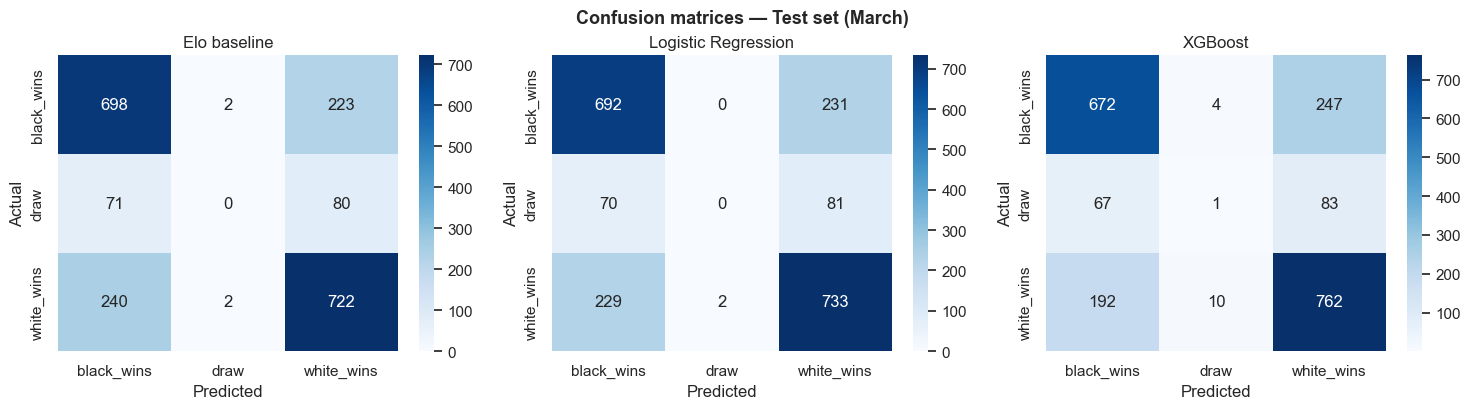

In [13]:
fig = plot_confusion_matrices(output["results_test"])
fig.suptitle("Confusion matrices — Test set (March)", fontsize=13, fontweight="bold", y=1.02)
plt.show()

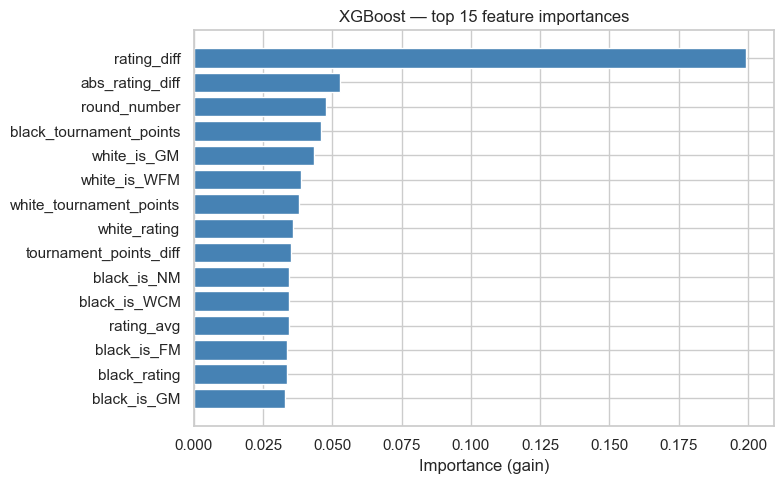

In [14]:
fig = plot_feature_importance(output["xgb_model"], feature_cols, top_n=15)
plt.show()

In [15]:
# Logistic Regression coefficients — interpretability check
lr = output["lr_model"].named_steps["lr"]
coef_df = pd.DataFrame(
    lr.coef_,
    index=["black_wins", "draw", "white_wins"],
    columns=feature_cols,
).T.round(3)
print("Logistic Regression coefficients (top 10 by |white_wins| coef):")
coef_df.reindex(coef_df["white_wins"].abs().sort_values(ascending=False).index).head(10)

Logistic Regression coefficients (top 10 by |white_wins| coef):


,black_wins,draw,white_wins
rating_diff,-0.190,-0.188,0.378
black_rating,0.007,0.230,-0.237
white_is_WFM,0.235,-0.461,0.226
round_number,-0.173,-0.027,0.201
elo_expected_score,-0.465,0.277,0.188
white_rating,-0.180,0.044,0.136
white_is_GM,-0.019,-0.085,0.104
white_is_NM,-0.029,0.127,-0.098
black_is_WCM,0.038,0.047,-0.084
white_is_WGM,-0.023,0.098,-0.075


## 5. Discussion & Next Steps

### Data split
The train/test split is **temporal**: February 2026 tournament → train, March 2026 tournament → test. This mirrors the production scenario where a model trained on past tournaments predicts future ones. A random split would leak within-tournament player form and inflate test metrics. Cross-validation within training is also round-based for the same reason.

### Model quality assessment

| Model | Test log-loss | Test accuracy |
|---|---|---|
| Elo baseline | 0.7352 | 69.7% |
| Logistic Regression | 0.7631 | 69.9% |
| XGBoost | 0.7824 | 70.4% |

**The Elo baseline is remarkably hard to beat.** Logistic Regression is actually *worse* on log-loss than the Elo baseline, meaning its probability estimates are less calibrated even though its accuracy is marginally higher. XGBoost achieves the best accuracy but its train log-loss (0.45) vs test log-loss (0.78) reveals significant overfitting — it memorizes training patterns that don't generalize across tournaments.

**Draw prediction is essentially unsolved.** Draws represent only ~8% of games and are nearly impossible to predict from pre-game information alone. All models collapse to near-zero F1 on draws in the test set. This is expected: whether two equally-rated players agree to a draw depends on tactical nuances of the position, not on who they are before the game starts.

**Rating difference dominates.** XGBoost's top feature by a large margin is `rating_diff`, confirming that the Elo formula already captures most of the predictive signal available before a game starts.

### What I would do next
- **Fetch player historical stats** via `/pub/player/{username}/stats` — blitz win rate, recent form over last 30 days, performance as White vs Black specifically
- **Head-to-head history** between the paired players (some matchups have well-established patterns)
- **More training data** — stack multiple Titled Tuesday tournaments rather than training on a single event (~2000 games is small for a 28-feature model)
- **Calibration analysis** — reliability diagrams to check if predicted probabilities match empirical frequencies; the Elo baseline likely needs isotonic regression calibration
- **Ordinal regression** — win > draw > loss has a natural ordering that multinomial logistic regression ignores
- **Opening repertoire features** — not the opening played, but each player's *tendency* (e.g., percentage of games as White that reach open games) can be computed from historical data without using the current game's moves